Loaded data from outputs/detection_yolo_fastest_v2/version_19/training_summary.json


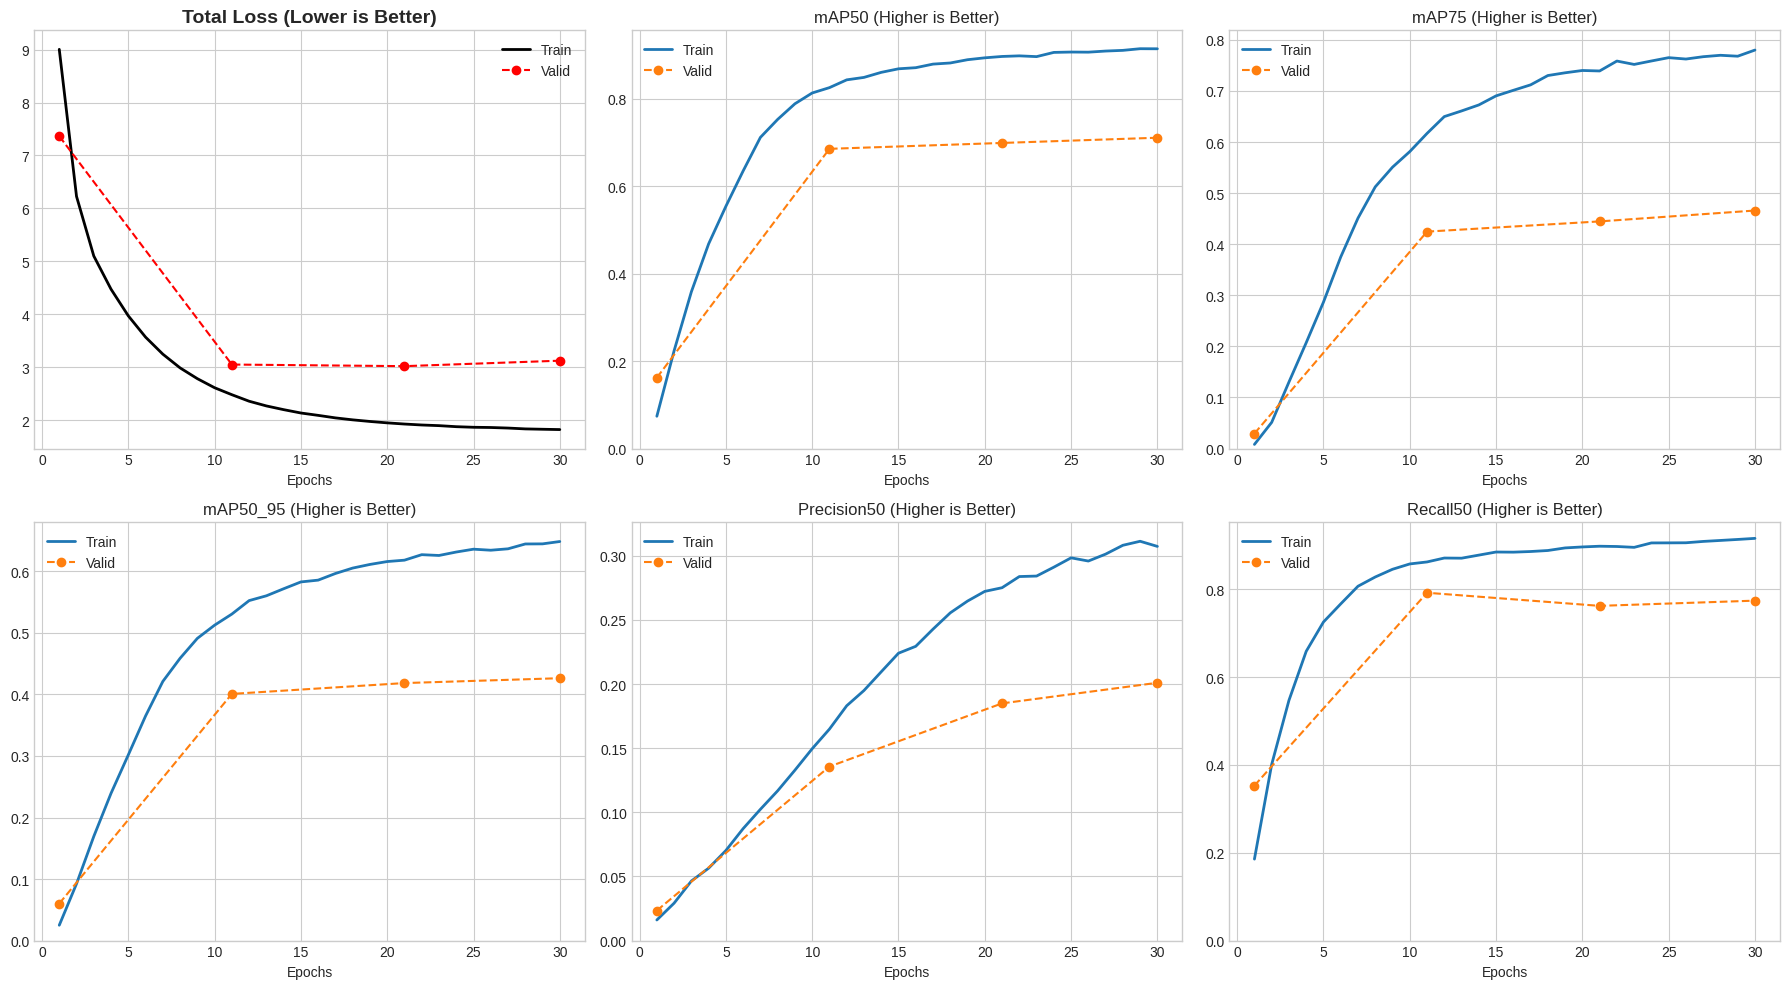

In [1]:
import json
import matplotlib.pyplot as plt
import math

# --- STEP 1: LOAD DATA ---
file_path = 'outputs/detection_yolo_fastest_v2/version_19/training_summary.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
    print(f"Loaded data from {file_path}")
except FileNotFoundError:
    print("File not found. Please check the path.")
    # For demo purposes, if file fails, we won't crash the cell
    data = None

if data:
    # --- STEP 2: PREPARE DATA ---
    # Get all epochs
    epochs = sorted([int(k) for k in data['train_losses'].keys()])
    valid_epochs = sorted([int(k) for k in data['valid_losses'].keys()])

    # Get list of all metrics available (e.g., ['mAP50', 'mAP75', 'Precision50', ...])
    metric_names = data.get('metrics_list', ['mAP50']) 
    
    # Calculate how many plots we need: 1 for Loss + N for metrics
    total_plots = 1 + len(metric_names)
    cols = 3
    rows = math.ceil(total_plots / cols)

    # --- STEP 3: DYNAMIC PLOTTING ---
    plt.style.use('seaborn-v0_8-whitegrid') # A nice clean style
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = axes.flatten() # Make it easier to iterate

    # -- PLOT 1: LOSS (The most important one) --
    train_loss = [data['train_losses'][str(e)] for e in epochs]
    valid_loss = [data['valid_losses'][str(e)] for e in valid_epochs]
    
    ax = axes[0]
    ax.plot(epochs, train_loss, label='Train', color='black', linewidth=2)
    ax.plot(valid_epochs, valid_loss, label='Valid', color='red', marker='o', linestyle='--')
    ax.set_title("Total Loss (Lower is Better)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epochs")
    ax.legend()

    # -- PLOT 2...N: ALL METRICS --
    for i, metric in enumerate(metric_names):
        ax = axes[i + 1] # Skip the first slot (Loss)
        
        # Extract Train Data for this specific metric
        # Note: Some epochs might miss metrics if training crashed, so we use .get()
        y_train = []
        for e in epochs:
            try:
                val = data['train_metrics'][str(e)][metric]['mean']
            except KeyError:
                val = 0.0 # Default to 0 if missing
            y_train.append(val)

        # Extract Valid Data
        y_valid = []
        for e in valid_epochs:
            try:
                val = data['valid_metrics'][str(e)][metric]['mean']
            except KeyError:
                val = 0.0
            y_valid.append(val)

        # Plot
        ax.plot(epochs, y_train, label='Train', linewidth=2)
        ax.plot(valid_epochs, y_valid, label='Valid', marker='o', linestyle='--')
        
        ax.set_title(f"{metric} (Higher is Better)", fontsize=12)
        ax.set_xlabel("Epochs")
        ax.set_ylim(bottom=0) # Lock bottom to 0 for easier reading
        ax.legend()

    # Hide empty subplots if any
    for i in range(total_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

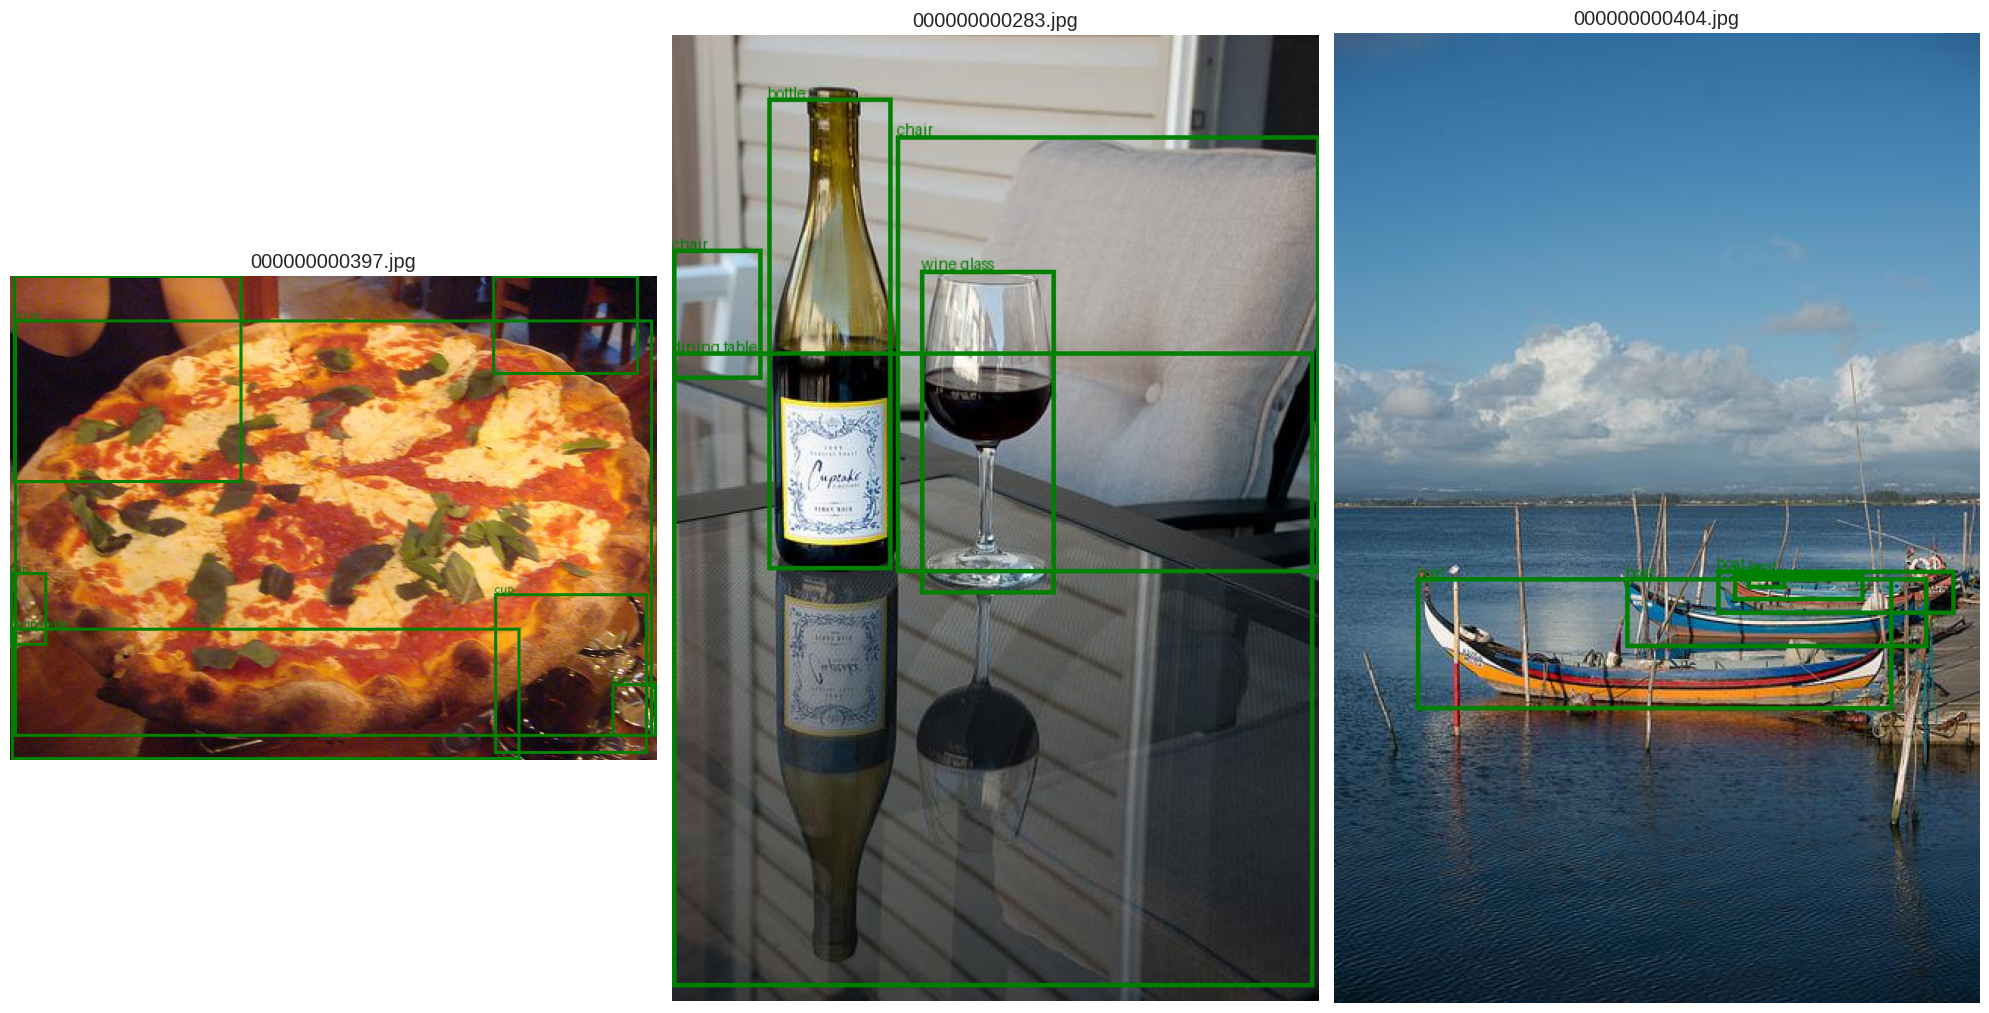

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# --- CONFIGURATION ---
# Adjust these paths if your folder structure is different
IMG_DIR = 'data/coco128/images/train2017'
LABEL_DIR = 'data/coco128/labels/train2017'

# COCO 80 Class Names (Standard List)
CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush"
]

def get_random_files(img_dir, num=4):
    """Picks random images that have a corresponding label file."""
    all_imgs = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    valid_files = []
    
    # Simple check to ensure label file exists
    for img_file in all_imgs:
        label_file = os.path.splitext(img_file)[0] + ".txt"
        if os.path.exists(os.path.join(LABEL_DIR, label_file)):
            valid_files.append(img_file)
            
    return random.sample(valid_files, min(num, len(valid_files)))

def draw_boxes(img_name):
    """Loads image and label, draws boxes."""
    img_path = os.path.join(IMG_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, os.path.splitext(img_name)[0] + ".txt")
    
    # Load Image
    try:
        image = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"Error loading {img_name}: {e}")
        return None

    width, height = image.size
    draw = ImageDraw.Draw(image)
    
    # Read Labels
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            cls_id = int(parts[0])
            # YOLO Format: center_x, center_y, w, h (normalized 0-1)
            cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            
            # Convert to Pixels
            box_w = w * width
            box_h = h * height
            x1 = (cx * width) - (box_w / 2)
            y1 = (cy * height) - (box_h / 2)
            x2 = x1 + box_w
            y2 = y1 + box_h
            
            # Draw Box & Text
            color = "green"
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            
            # Draw Label Name
            label_text = f"{CLASSES[cls_id] if cls_id < len(CLASSES) else cls_id}"
            draw.text((x1, y1 - 10), label_text, fill=color)
            
    return image

# --- MAIN VISUALIZATION ---
# Pick 3 random images
samples = get_random_files(IMG_DIR, num=3)

plt.figure(figsize=(20, 10))
for i, img_name in enumerate(samples):
    img_with_boxes = draw_boxes(img_name)
    
    if img_with_boxes:
        plt.subplot(1, 3, i+1)
        plt.imshow(img_with_boxes)
        plt.title(img_name)
        plt.axis('off')

plt.tight_layout()
plt.show()